# CNN: VGG16 Workshop Tutorial

This notebook demonstrates a StarV robustness workflow for an ImageNet VGG16 classifier. It loads a VGG16 network, reads a VNN-LIB perturbation property, builds ImageStar and SparseImageStar input sets, verifies robustness with approximate BFS reachability, and visualizes the output score ranges.

## 1. Setup

Import the StarV utilities used in the tutorial and define small helper functions for result formatting and ImageNet visualization.

In [1]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import StarV
import torchvision.models as models

from StarV.set.imagestar import ImageStar
from StarV.set.sparseimagestar2dcoo import SparseImageStar2DCOO
from StarV.set.sparseimagestar2dcsr import SparseImageStar2DCSR
from StarV.util.load import load_neural_network, load_neural_network_file
from StarV.util.vnnlib import get_num_inputs_outputs, read_vnnlib_simple
from StarV.verifier.certifier import certifyRobustness

# repo_root points at the repository root that contains the StarV package folder.
repo_root = Path(StarV.__file__).resolve().parents[1]

# ImageNet VNN-LIB files store inputs after torchvision normalization:
# normalized = (pixel - mean) / std, with pixel values in [0, 1].
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
IMAGENET_STD = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)


def robustness_verification_result_to_string(result):
    """Convert StarV's numeric robustness code to tutorial-friendly text."""
    if result == 1:
        return 'ROBUST'
    if result == 2:
        return 'UNKNOWN'
    if result == 0:
        return 'UNROBUST'
    raise ValueError(f"Unknown robustness verification result: {result}")


def imagenet_unnormalize(normalized_image):
    """Convert an HWC ImageNet-normalized image back to display range [0, 1]."""
    return np.clip(normalized_image * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)


def summarize_verification(name, result, reach_time):
    """Print one compact verification summary line."""
    result_text = robustness_verification_result_to_string(result)
    print(f"{name}: {result_text} in {reach_time:.3f} seconds")

## 2. Load The PyTorch VGG16 Network

This tutorial uses TorchVision's pretrained ImageNet VGG16 model and converts it into StarV layers. The ImageNet input shape is `(3, 224, 224)`, and the classifier returns 1000 output logits.

In [2]:
net_type = 'VGG16_CNN'
starv_dtype = 'float64'
image_shape = (3, 224, 224)
num_inputs = int(np.prod(image_shape))
num_outputs = 1000
inp_dtype = np.float64

# Load the pretrained PyTorch VGG16 model and set it to inference mode.
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
model.eval()

# Convert the PyTorch model into a StarV neural network.
# channel_last=False keeps the flattening order consistent with ImageNet [C, H, W] inputs.
net = load_neural_network(model, net_type=net_type, dtype=starv_dtype, channel_last=False)

print('Model source: TorchVision pretrained VGG16')
print(net)

torch.nn.modules.container.Sequential layer is neglected in the analysis
torch.nn.modules.container.Sequential layer is neglected in the analysis
Model source: TorchVision pretrained VGG16

=============NETWORK===============
Network type: VGG16_CNN
Input Dimension: 3
Output Dimension: 1000
Number of Layers: 37
Layer types:
Layer 0: <class 'StarV.layer.Conv2DLayer.Conv2DLayer'> (3, 64, kernel_size = (3, 3), stride = [1 1], padding = [1 1 1 1], dilation = [1 1], dtype=float64)
Layer 1: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 2: <class 'StarV.layer.Conv2DLayer.Conv2DLayer'> (64, 64, kernel_size = (3, 3), stride = [1 1], padding = [1 1 1 1], dilation = [1 1], dtype=float64)
Layer 3: <class 'StarV.layer.ReLULayer.ReLULayer'>
Layer 4: <class 'StarV.layer.MaxPool2DLayer.MaxPool2DLayer'> (kernel_size = [2 2], stride = [2 2], padding = [0 0])
Layer 5: <class 'StarV.layer.Conv2DLayer.Conv2DLayer'> (64, 128, kernel_size = (3, 3), stride = [1 1], padding = [1 1 1 1], dilation = [1 1], dty

## 3. Read The VNN-LIB Property

The VNN-LIB property gives a normalized ImageNet input box and output constraints. The input variables are flattened in channel-first order `[C, H, W]`; StarV image sets use channel-last arrays `[H, W, C]`, so the bounds are reshaped and transposed.

Reading VNN-LIB property: StarV/util/data/nets/vggnet16/vnnlib/spec9_Border_terrier.vnnlib
Verifying spec9_Border_terrier with 20 attacked scalar pixel values
ImageNet label index: 182


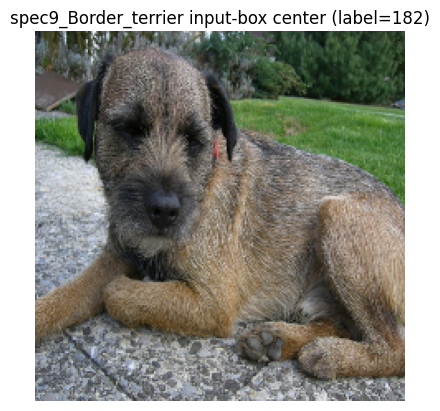

In [3]:
spec_file = 'StarV/util/data/nets/vggnet16/vnnlib/spec9_Border_terrier.vnnlib'
spec_path = repo_root / spec_file
bounds_dtype = np.float64

print(f'Reading VNN-LIB property: {spec_file}')
vnnlib_rv = read_vnnlib_simple(str(spec_path), num_inputs, num_outputs)
box, spec_list = vnnlib_rv[0]
bounds = np.array(box, dtype=bounds_dtype)

# The first comment line contains the ImageNet label used by the benchmark.
with open(spec_path) as f:
    first_line = f.readline().strip()
label = int(re.findall(r'\b\d+\b', first_line)[0])

# Convert flattened [C, H, W] bounds to StarV's image layout [H, W, C].
lb = bounds[:, 0].reshape(image_shape).transpose([1, 2, 0])
ub = bounds[:, 1].reshape(image_shape).transpose([1, 2, 0])

num_attack_pixel = int((lb != ub).sum())
spec_name = spec_path.stem
print(f'Verifying {spec_name} with {num_attack_pixel} attacked scalar pixel values')
print(f'ImageNet label index: {label}')

# Plot the center of the input box in normal image space.
normalized_center = 0.5 * (lb + ub)
image_to_plot = imagenet_unnormalize(normalized_center)

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(image_to_plot)
ax.set_title(f'{spec_name} input-box center (label={label})')
ax.axis('off')
plt.show()

## 4. Robustness Verification

The next cell constructs three equivalent input-set representations and verifies each one with approximate BFS reachability. The ImageStar output set is retained for the output-range plot in the following section.

For robustness verification, the input set $X$ is usually a perturbation set around one nominal input $x_0$.

For an $L_\infty$ perturbation with radius $\epsilon$, the robust input set is

$$
X_{rob} = \{x : \lVert x - x_0 \rVert_\infty \leq \epsilon\}.
$$

Given the true class label $c$, robustness means that every admissible input in this set is classified as class $c$:

$$
\forall x \in X_{rob}, \quad f_c(x) \geq \max_{i \neq c} f_i(x).
$$

StarV verifies this condition by propagating the whole input set through the network and comparing output score ranges for the label against the competing classes.

LP solver options: 'gurobi', 'glpk', 'linprog', 'estimate'

In [4]:
reachability_method = 'approx'
lp_solver = 'gurobi'

print(f'Reachability method: {reachability_method}')
print(f'LP solver: {lp_solver}')

Reachability method: approx
LP solver: gurobi


In [5]:
input_sets = {
    'ImageStar': ImageStar(lb, ub),
    'SparseImageStar2DCSR': SparseImageStar2DCSR(lb, ub),
    'SparseImageStar2DCOO': SparseImageStar2DCOO(lb, ub),
}

verification_results = {}

for set_name, input_set in input_sets.items():
    result, reach_time, total_time, output_set = certifyRobustness(
        net=net,                            # network to verify
        inputs=input_set,                   # input set to verify
        labels=label,                       # true label index for robustness verification
        veriMethod='BFS',                   # verification method
        reachMethod=reachability_method,    # reachability method
        lp_solver=lp_solver,                # LP solver to use for optimization queries
    )
    verification_results[set_name] = {
        'result': result,
        'reach_time': reach_time,
        'total_time': total_time,
        'output_set': output_set,
    }
    summarize_verification(set_name, result, reach_time)

# The dense ImageStar output set is used below for the score-range figure.
IM_output_set = verification_results['ImageStar']['output_set']

ImageStar: ROBUST in 17.345 seconds
SparseImageStar2DCSR: ROBUST in 80.151 seconds
SparseImageStar2DCOO: ROBUST in 86.137 seconds


## 5. Plot Output Score Ranges

For robustness, the true label must dominate every competing class over the whole input set. A sufficient certificate is:

`lower_bound[label] > max(upper_bound[j] for j != label)`

The plot shows the true-label range and the top competing ranges by upper bound.

Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-10


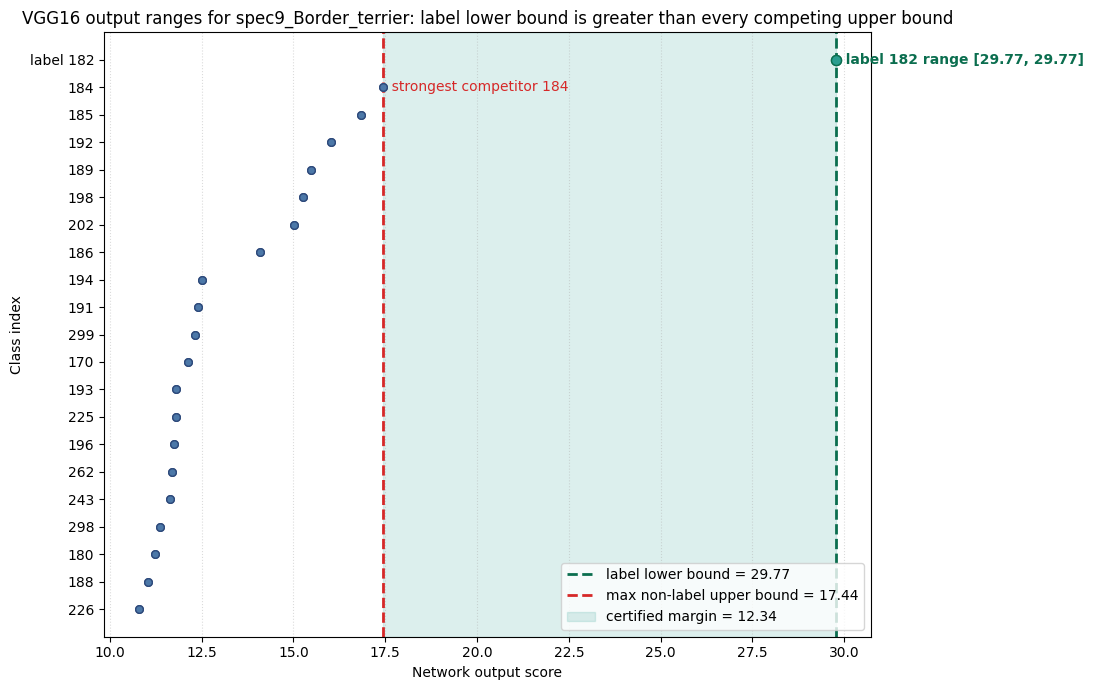

Label index: 182
Label range: [29.77289742161048, 29.77290501341953]
Max non-label upper bound: class 184, upper=17.437575225603563
Certified margin lower_bound[label] - max_upper_bound[others]: 12.335322196006917


In [6]:
lower_bound, upper_bound = IM_output_set.getRanges(lp_solver=lp_solver)
lower_bound = np.asarray(lower_bound, dtype=float).ravel()
upper_bound = np.asarray(upper_bound, dtype=float).ravel()

label_index = int(label)
all_indices = np.arange(num_outputs)
other_indices = np.setdiff1d(all_indices, [label_index])
max_other_upper_index = int(other_indices[np.argmax(upper_bound[other_indices])])
certified_margin = lower_bound[label_index] - upper_bound[max_other_upper_index]

# Plot the true label interval with the strongest competing intervals.
top_k = 20
competitor_indices = other_indices[np.argsort(upper_bound[other_indices])[-top_k:]][::-1]
plot_indices = np.concatenate(([label_index], competitor_indices))
plot_labels = [f'label {label_index}' if idx == label_index else str(idx) for idx in plot_indices]
y_positions = np.arange(len(plot_indices))

fig, ax = plt.subplots(figsize=(11, 7))

for pos, class_index in enumerate(plot_indices):
    is_label = class_index == label_index
    color = '#2A9D8F' if is_label else '#4C78A8'
    edgecolor = '#0B6E4F' if is_label else '#2F4B7C'
    linewidth = 3.2 if is_label else 1.8
    marker_size = 52 if is_label else 30

    # The left dot is the lower bound, the right dot is the upper bound.
    ax.plot(
        [lower_bound[class_index], upper_bound[class_index]],
        [pos, pos],
        color=color,
        linewidth=linewidth,
        solid_capstyle='round',
        zorder=3 if is_label else 2,
    )
    ax.scatter(
        [lower_bound[class_index], upper_bound[class_index]],
        [pos, pos],
        color=color,
        edgecolor=edgecolor,
        s=marker_size,
        zorder=4 if is_label else 3,
    )

label_lower = lower_bound[label_index]
max_other_upper = upper_bound[max_other_upper_index]

ax.axvline(
    label_lower,
    color='#0B6E4F',
    linestyle='--',
    linewidth=2.0,
    label=f'label lower bound = {label_lower:.4g}',
)
ax.axvline(
    max_other_upper,
    color='#D62828',
    linestyle='--',
    linewidth=2.0,
    label=f'max non-label upper bound = {max_other_upper:.4g}',
)

if certified_margin > 0:
    ax.axvspan(
        max_other_upper,
        label_lower,
        color='#2A9D8F',
        alpha=0.16,
        label=f'certified margin = {certified_margin:.4g}',
    )
    title_status = 'label lower bound is greater than every competing upper bound'
else:
    ax.axvspan(
        label_lower,
        max_other_upper,
        color='#D62828',
        alpha=0.12,
        label=f'overlap = {-certified_margin:.4g}',
    )
    title_status = 'label range does not dominate all competitors'

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_labels)
ax.invert_yaxis()
ax.set_xlabel('Network output score')
ax.set_ylabel('Class index')
ax.set_title(f'VGG16 output ranges for {spec_name}: {title_status}')
ax.grid(axis='x', linestyle=':', alpha=0.45)
ax.legend(loc='lower right')

ax.text(
    upper_bound[label_index],
    0,
    f'  label {label_index} range [{lower_bound[label_index]:.4g}, {upper_bound[label_index]:.4g}]',
    va='center',
    ha='left',
    color='#0B6E4F',
    fontweight='bold',
)
competitor_pos = int(np.where(plot_indices == max_other_upper_index)[0][0])
ax.text(
    max_other_upper,
    competitor_pos,
    f'  strongest competitor {max_other_upper_index}',
    va='center',
    ha='left',
    color='#D62828',
)

plt.tight_layout()
plt.show()

print(f'Label index: {label_index}')
print(f'Label range: [{lower_bound[label_index]}, {upper_bound[label_index]}]')
print(f'Max non-label upper bound: class {max_other_upper_index}, upper={max_other_upper}')
print(f'Certified margin lower_bound[label] - max_upper_bound[others]: {certified_margin}')

## 6. Optional Layer Profiling

The following cell can be enabled to compare per-layer runtime and memory usage for ImageStar, SparseImageStar COO, and SparseImageStar CSR. It is disabled by default because it reruns the full network reachability layer by layer.

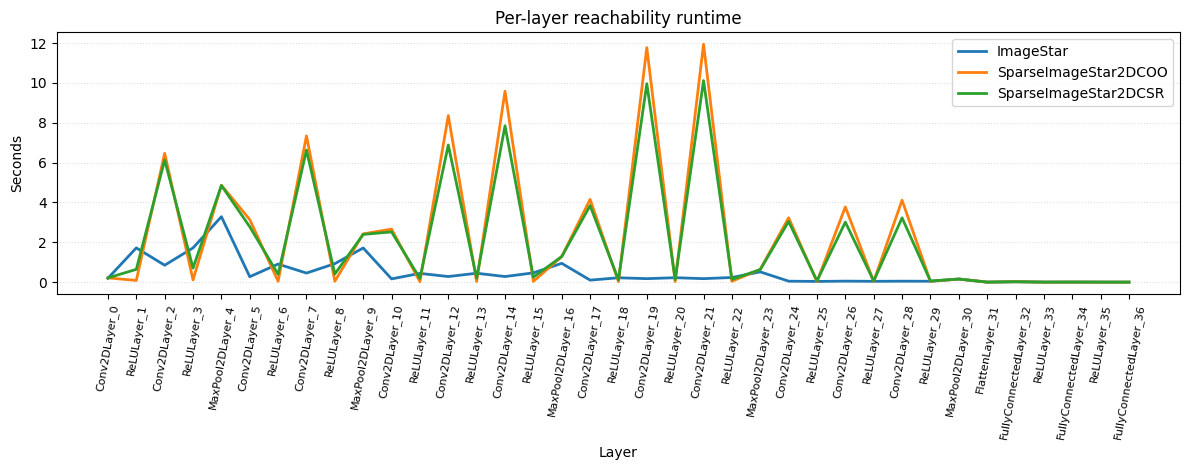

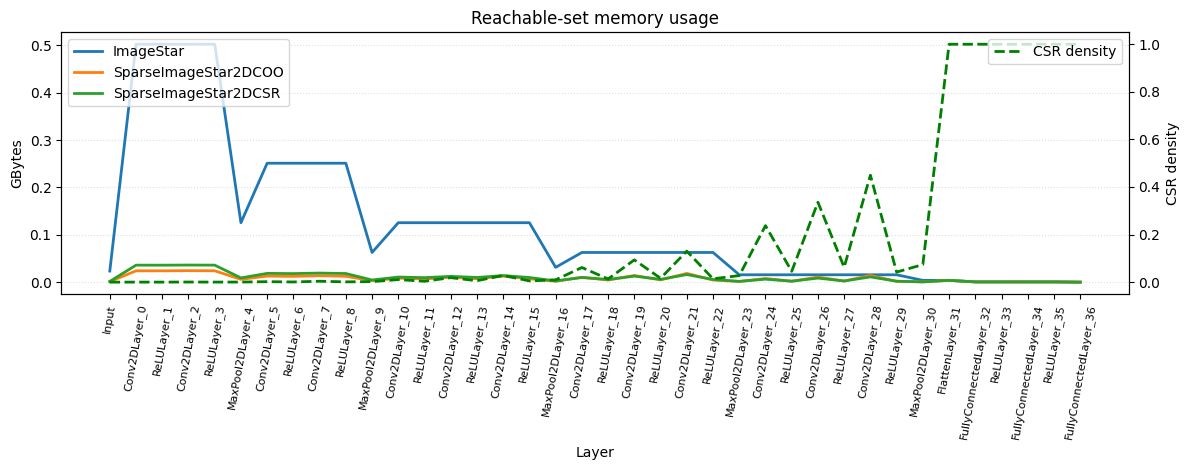

In [7]:
RUN_LAYER_PROFILE = True

if RUN_LAYER_PROFILE:
    profile_sets = {
        'ImageStar': ImageStar(lb, ub),
        'SparseImageStar2DCOO': SparseImageStar2DCOO(lb, ub),
        'SparseImageStar2DCSR': SparseImageStar2DCSR(lb, ub),
    }
    profile_time = {name: [] for name in profile_sets}
    profile_memory = {name: [set_obj.nbytes() / (1024**3)] for name, set_obj in profile_sets.items()}  # Convert to GBytes
    csr_density = [profile_sets['SparseImageStar2DCSR'].density()]

    for layer_index, layer in enumerate(net.layers):
        for set_name, set_obj in list(profile_sets.items()):
            start = time.perf_counter()
            profile_sets[set_name] = layer.reach(set_obj, method=reachability_method, lp_solver=lp_solver, show=False)
            profile_time[set_name].append(time.perf_counter() - start)
            profile_memory[set_name].append(profile_sets[set_name].nbytes() / (1024**3))  # Convert to GBytes
        csr_density.append(profile_sets['SparseImageStar2DCSR'].density())

    layer_ids = np.arange(net.n_layers)
    layer_labels = [f'{layer.__class__.__name__}_{i}' for i, layer in enumerate(net.layers)]

    fig, ax = plt.subplots(figsize=(12, 4.8))
    for set_name, times in profile_time.items():
        ax.plot(layer_ids, times, linewidth=2, label=set_name)
    ax.set_title('Per-layer reachability runtime')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Seconds')
    ax.set_xticks(layer_ids)
    ax.set_xticklabels(layer_labels, rotation=80, fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

    memory_ids = np.arange(net.n_layers + 1)
    memory_labels = ['Input', *layer_labels]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    for set_name, memory in profile_memory.items():
        ax.plot(memory_ids, memory, linewidth=2, label=set_name)
    ax.set_title('Reachable-set memory usage')
    ax.set_xlabel('Layer')
    ax.set_ylabel('GBytes')
    ax.set_xticks(memory_ids)
    ax.set_xticklabels(memory_labels, rotation=80, fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.legend(loc='upper left')

    ax_density = ax.twinx()
    ax_density.plot(memory_ids, csr_density, color='green', linewidth=2, linestyle='--', label='CSR density')
    ax_density.set_ylabel('CSR density')
    ax_density.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('Set RUN_LAYER_PROFILE = True to run the optional layer profiling cell.')